In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/HRDataset_v14.csv')
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [5]:
# average salary department-wise
df.groupby('Department')['Salary'].mean()

,Salary
Department,
Admin Offices,71791.888889
Executive Office,250000.000000
IT/IS,97064.640000
Production,59953.545455
Sales,69061.258065
Software Engineering,94989.454545


In [6]:
# highest-paid and lowest-paid employees

highest_paid = df.sort_values(by='Salary', ascending=False).head(1)
lowest_paid = df.sort_values(by='Salary', ascending=True).head(1)

print("Highest Paid Employee:")
display(highest_paid[['Employee_Name', 'Department', 'Salary']])

print("\nLowest Paid Employee:")
display(lowest_paid[['Employee_Name', 'Department', 'Salary']])

Highest Paid Employee:


,Employee_Name,Department,Salary
150,"King, Janet",Executive Office,250000



Lowest Paid Employee:


,Employee_Name,Department,Salary
310,"Zima, Colleen",Production,45046


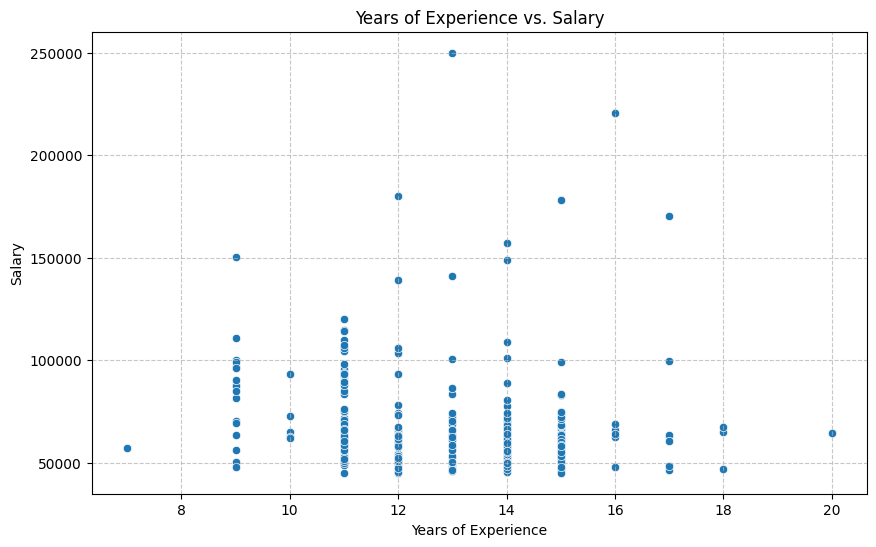

In [9]:
# relationship between experience and salary

df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['YearsOfExperience'] = (pd.Timestamp.now() - df['DateofHire']).dt.days // 365

plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsOfExperience', y='Salary', data=df)
plt.title('Years of Experience vs. Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
# salary outliers
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,YearsOfExperience
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1,14
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17,11
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3,14
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15,18
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2,14


In [11]:
q1 = df['Salary'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
outliers

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,YearsOfExperience
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17,11
18,"Becker, Renee",10245,0,0,0,4,3,3,0,110000,...,4.0,Google Search,Fully Meets,4.50,4,5,1/15/2015,0,8,11
25,"Booth, Frank",10199,0,0,1,4,3,3,0,103613,...,4.0,LinkedIn,Fully Meets,3.50,5,7,1/10/2016,0,2,12
26,"Boutwell, Bonalyn",10081,1,1,0,1,1,3,1,106367,...,3.0,Diversity Job Fair,Fully Meets,5.00,4,3,2/18/2019,0,4,11
39,"Carr, Claudia N",10082,0,0,0,2,3,3,0,100031,...,4.0,LinkedIn,Fully Meets,5.00,5,6,2/18/2019,0,7,9
42,"Champaigne, Brian",10108,1,1,1,1,3,3,0,110929,...,5.0,Indeed,Fully Meets,4.50,5,7,1/15/2019,0,8,9
55,"Corleone, Vito",10019,0,0,1,1,5,4,0,170500,...,2.0,Indeed,Exceeds,3.70,5,0,2/4/2019,0,15,17
66,"Del Bosque, Keyla",10155,0,0,0,1,4,3,0,101199,...,10.0,CareerBuilder,Fully Meets,3.79,5,5,1/25/2019,0,8,14
76,"Dougall, Eric",10028,0,0,1,1,3,4,0,138888,...,5.0,Indeed,Exceeds,4.30,5,5,1/4/2019,0,4,12
86,"Exantus, Susan",10290,1,1,0,4,4,2,0,99280,...,10.0,Indeed,Needs Improvement,2.10,5,4,8/10/2012,4,19,15


Text(0, 0.5, 'Frequency')

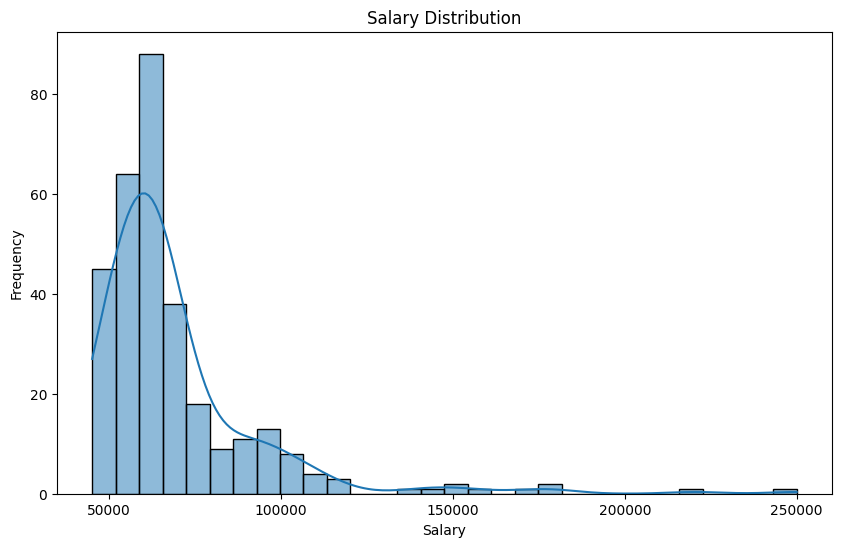

In [12]:
# salary distribution histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')

Text(0, 0.5, 'Salary')

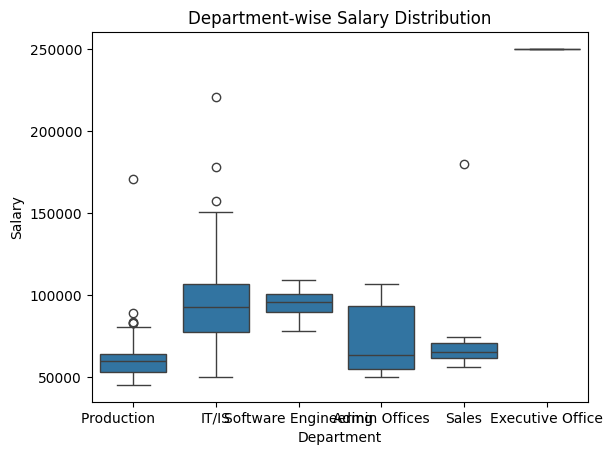

In [13]:
# Department wise boxplot
sns.boxplot(x='Department', y='Salary', data=df)
plt.title('Department-wise Salary Distribution')
plt.xlabel('Department')
plt.ylabel('Salary')

Text(0, 0.5, 'Salary')

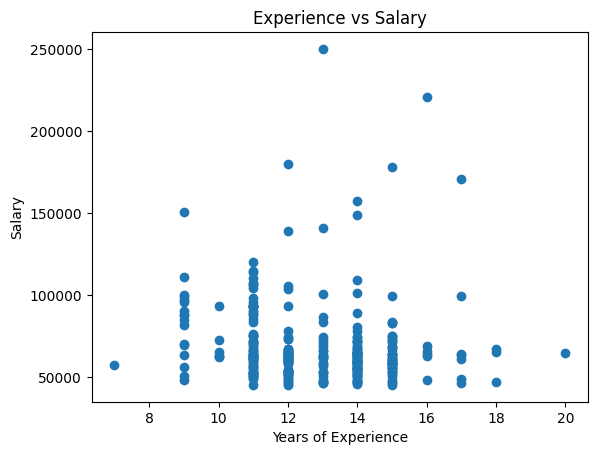

In [14]:
# experience vs salary scatter plot
plt.scatter(df['YearsOfExperience'], df['Salary'])
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

In [15]:
# HR improvements based on analysis
print("Standardize salary structure")
print('Reward experienced employees properly')
print('Investigate salary outliers')
print('Improve hiring in understaffed departments')

Standardize salary structure
Reward experienced employees properly
Investigate salary outliers
Improve hiring in understaffed departments
